# Data Visualization & EDA - COVID-19 Dataset

## Objective

- Perform exploratory data analysis on a COVID-19 dataset.
- Clean and prepare the dataset for analysis.
- Create visualizations to identify trends, correlations, and outliers.
- Analyze relationships between key metrics such as confirmed cases, deaths, and recoveries.
- Derive actionable insights to help stakeholders understand the impact of COVID-19.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load Dataset

In [2]:
df = pd.read_csv("../data/covid-19_data.csv")
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


## Basic Dataset Inspection

In [3]:
df.shape

(187, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    str    
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    str    
dtype

In [5]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,182.000000,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,40.558297,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,336.669357,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.442500,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.580000,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.232500,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,3259.260000,3.834677e+06,455582.000000,226.320000


## Check Missing Values

In [6]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    5
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [7]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("/", "_")

In [8]:
df.head()

,Country_Region,Confirmed,Deaths,Recovered,Active,New_cases,New_deaths,New_recovered,Deaths___100_Cases,Recovered___100_Cases,Deaths___100_Recovered,Confirmed_last_week,1_week_change,1_week_%_increase,WHO_Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


## Identify Top Countries by Confirmed Cases

In [9]:
top10 = df.sort_values("Confirmed", ascending=False).head(10)
top10

,Country_Region,Confirmed,Deaths,Recovered,Active,New_cases,New_deaths,New_recovered,Deaths___100_Cases,Recovered___100_Cases,Deaths___100_Recovered,Confirmed_last_week,1_week_change,1_week_%_increase,WHO_Region
173,US,4290259,148011,1325804,2816444,56336,1076,27941,3.45,30.90,11.16,3834677,455582,11.88,Americas
23,Brazil,2442375,87618,1846641,508116,23284,614,33728,3.59,75.61,4.74,2118646,323729,15.28,Americas
79,India,1480073,33408,951166,495499,44457,637,33598,2.26,64.26,3.51,1155338,324735,28.11,South-East Asia
138,Russia,816680,13334,602249,201097,5607,85,3077,1.63,73.74,2.21,776212,40468,5.21,Europe
154,South Africa,452529,7067,274925,170537,7096,298,9848,1.56,60.75,2.57,373628,78901,21.12,Africa
111,Mexico,395489,44022,303810,47657,4973,342,8588,11.13,76.82,14.49,349396,46093,13.19,Americas
132,Peru,389717,18418,272547,98752,13756,575,4697,4.73,69.93,6.76,357681,32036,8.96,Americas
35,Chile,347923,9187,319954,18782,2133,75,1859,2.64,91.96,2.87,333029,14894,4.47,Americas
177,United Kingdom,301708,45844,1437,254427,688,7,3,15.19,0.48,3190.26,296944,4764,1.60,Europe
81,Iran,293606,15912,255144,22550,2434,212,1931,5.42,86.90,6.24,276202,17404,6.30,Eastern Mediterranean


## VISUALIZATIONS

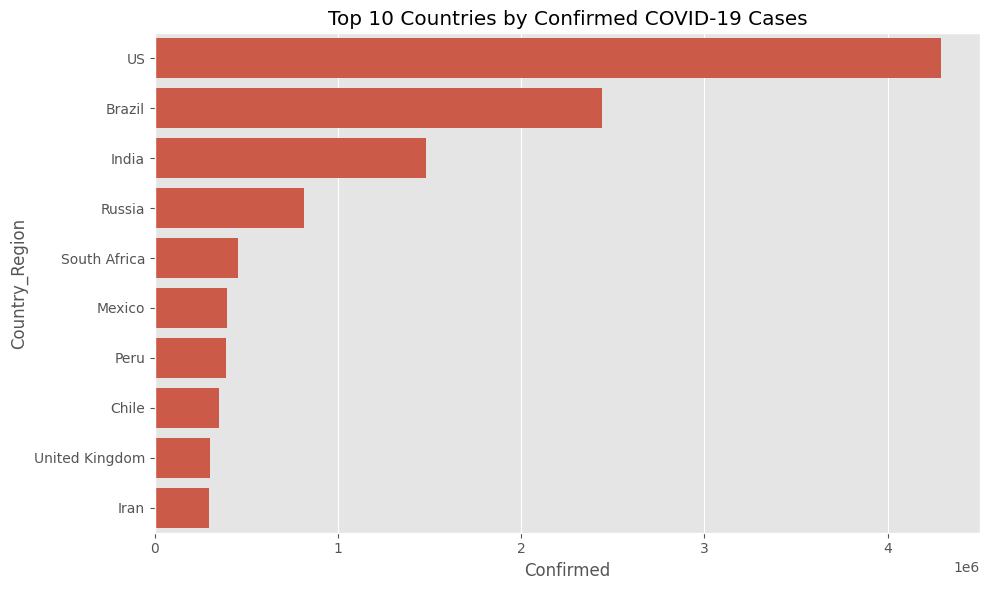


Stakeholder Insight: 
Highlights countries with the highest infection levels to help prioritize healthcare resources and policy interventions.



In [10]:
# Visualization 1  
# Top 10 Countries by Confirmed Cases

top10_cases = df.sort_values("Confirmed", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Confirmed", y="Country_Region", data=top10_cases)

plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.tight_layout()
plt.savefig("../images/top10_confirmed_cases.png")
plt.show()

print(
'''
Stakeholder Insight: 
Highlights countries with the highest infection levels to help prioritize healthcare resources and policy interventions.
'''
)

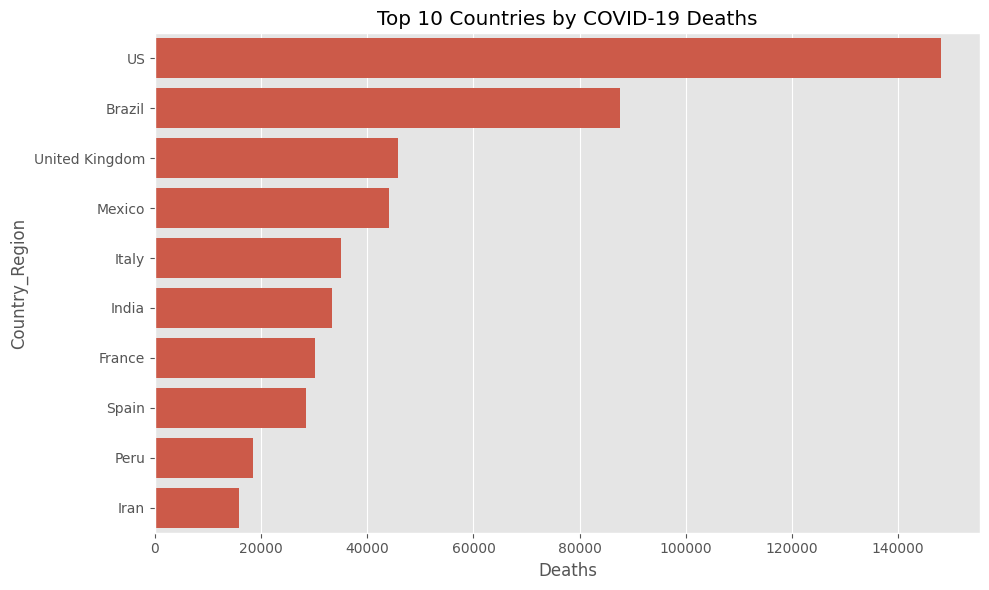


Stakeholder Insight:
Identifies regions experiencing the highest mortality impact, guiding global emergency response strategies.



In [11]:
# Visualization 2 
# Top 10 Countries by Deaths

top10_deaths = df.sort_values("Deaths", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Deaths", y="Country_Region", data=top10_deaths)

plt.title("Top 10 Countries by COVID-19 Deaths")
plt.tight_layout()
plt.savefig("../images/top10_deaths.png")
plt.show()

print(
'''
Stakeholder Insight:
Identifies regions experiencing the highest mortality impact, guiding global emergency response strategies.
'''
)

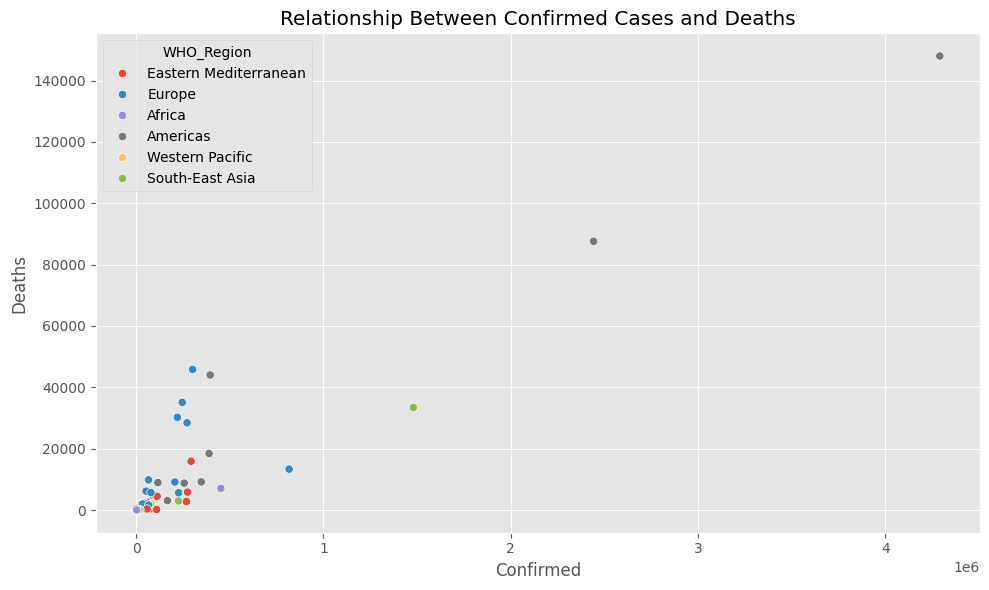


Stakeholder Insight:
Demonstrates that higher infection levels strongly correlate with higher mortality risk.



In [12]:
# Visualization 3
# Confirmed vs Deaths Relationship

plt.figure(figsize=(10,6))
sns.scatterplot(x="Confirmed", y="Deaths", hue="WHO_Region", data=df)

plt.title("Relationship Between Confirmed Cases and Deaths")
plt.tight_layout()
plt.savefig("../images/confirmed_vs_deaths.png")
plt.show()

print(
'''
Stakeholder Insight:
Demonstrates that higher infection levels strongly correlate with higher mortality risk.
'''
)

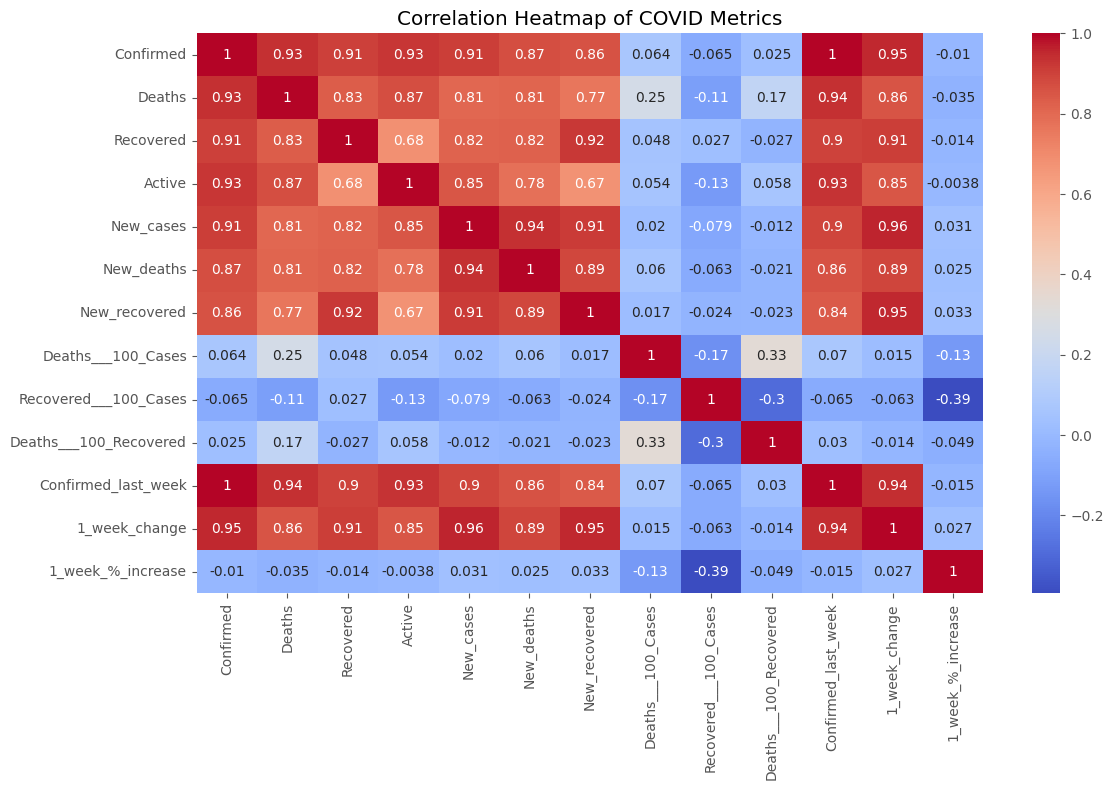


Stakeholder Insight:
Helps analysts understand relationships between pandemic indicators such as confirmed cases, deaths, and recoveries.



In [13]:
# Visualization 4
# Correlation Heatmap

plt.figure(figsize=(12,8))
correlation = df.corr(numeric_only=True)
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of COVID Metrics")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png")
plt.show()

print(
'''
Stakeholder Insight:
Helps analysts understand relationships between pandemic indicators such as confirmed cases, deaths, and recoveries.
'''
)

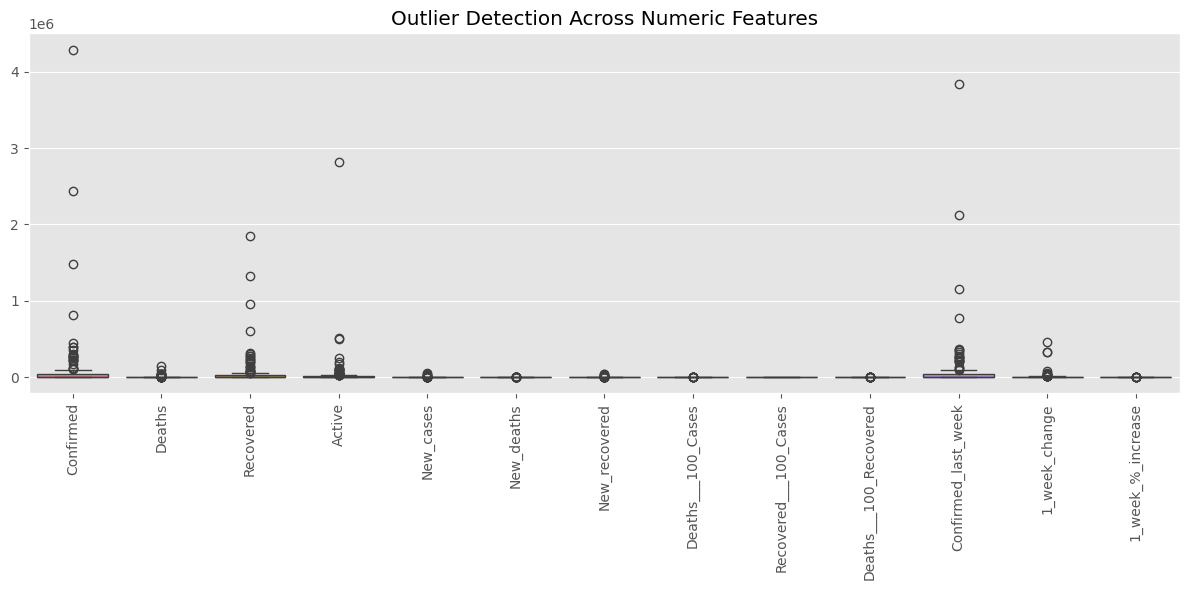


Stakeholder Insight:
Identifies extreme pandemic values representing countries experiencing unusually severe outbreaks.



In [14]:
# Visualization 5 
# Outlier Detection (Boxplot)
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12,6))
sns.boxplot(data=numeric_df)

plt.xticks(rotation=90)
plt.title("Outlier Detection Across Numeric Features")

plt.tight_layout()
plt.savefig("../images/numeric_boxplot.png")
plt.show()

print(
'''
Stakeholder Insight:
Identifies extreme pandemic values representing countries experiencing unusually severe outbreaks.
'''
)

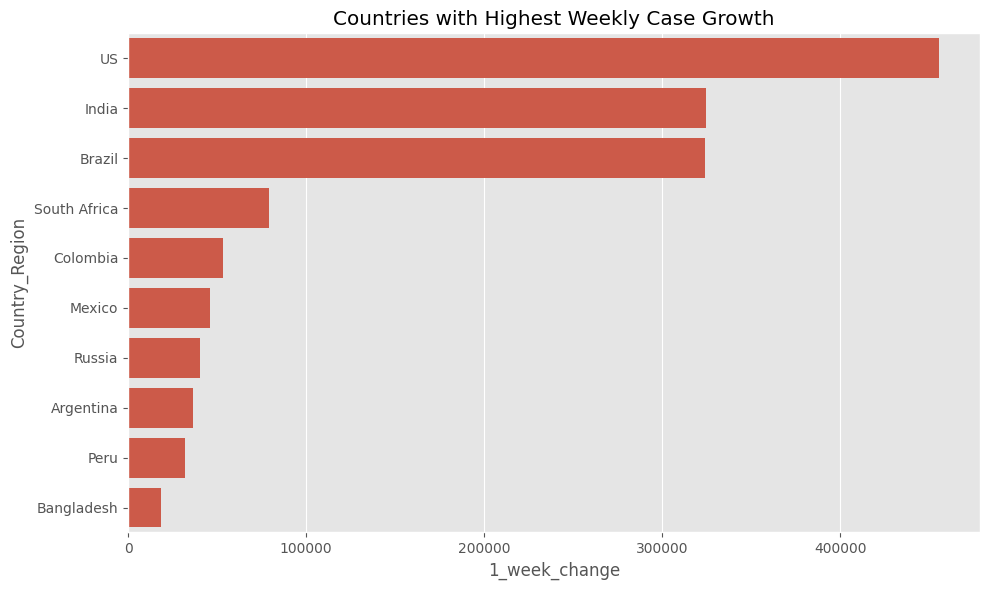


Stakeholder Insight:
Helps detect rapidly growing outbreaks where containment measures must be implemented immediately.



In [15]:
# Visualization 6  
# Weekly Case Growth Trend
top_growth = df.sort_values("1_week_change", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="1_week_change", y="Country_Region", data=top_growth)

plt.title("Countries with Highest Weekly Case Growth")
plt.tight_layout()
plt.savefig("../images/weekly_growth.png")
plt.show()

print(
'''
Stakeholder Insight:
Helps detect rapidly growing outbreaks where containment measures must be implemented immediately.
'''
)

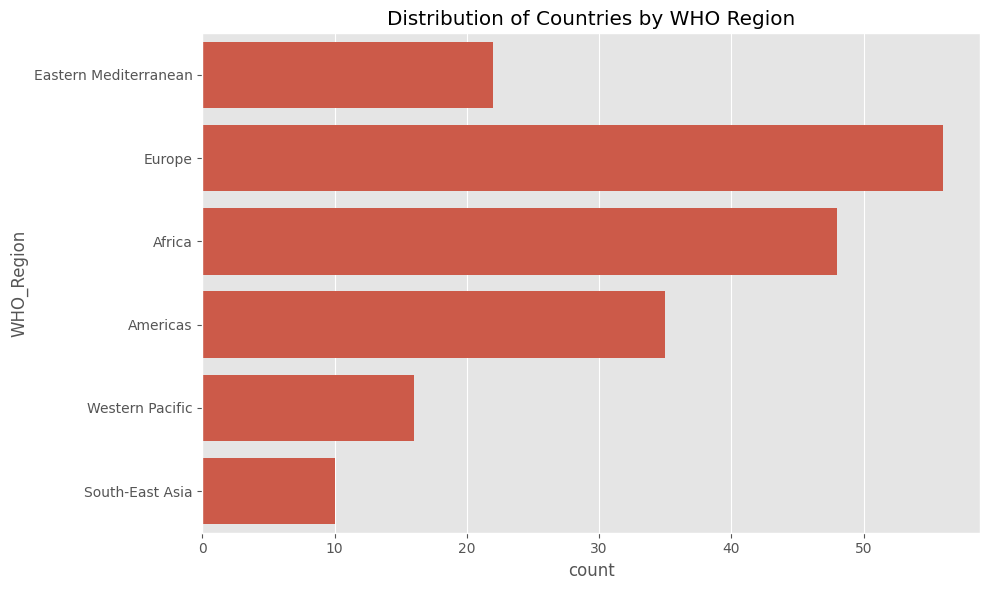


Stakeholder Insight:
Shows geographic spread of the pandemic across global health regions.



In [16]:
# Visualization 7 
# WHO Region Distribution
plt.figure(figsize=(10,6))
sns.countplot(y="WHO_Region", data=df)

plt.title("Distribution of Countries by WHO Region")
plt.tight_layout()
plt.savefig("../images/who_region_distribution.png")
plt.show()

print(
'''
Stakeholder Insight:
Shows geographic spread of the pandemic across global health regions.
'''
)

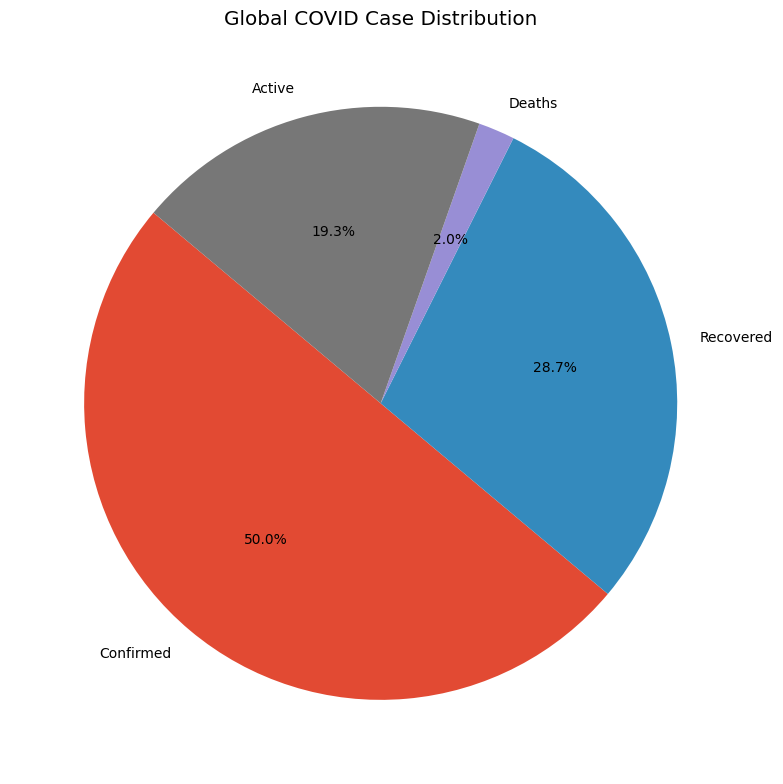


Stakeholder Insight:
Provides a quick overview of global pandemic status including active, recovered, and fatal cases.



In [17]:
# Visualization 8  
# Global Case Distribution 
totals = [
    df["Confirmed"].sum(),
    df["Recovered"].sum(),
    df["Deaths"].sum(),
    df["Active"].sum()
]

labels = ["Confirmed", "Recovered", "Deaths", "Active"]

plt.figure(figsize=(8,8))
plt.pie(totals, labels=labels, autopct='%1.1f%%', startangle=140)

plt.title("Global COVID Case Distribution")
plt.tight_layout()
plt.savefig("../images/global_case_distribution.png")
plt.show()

print(
'''
Stakeholder Insight:
Provides a quick overview of global pandemic status including active, recovered, and fatal cases.
'''
)

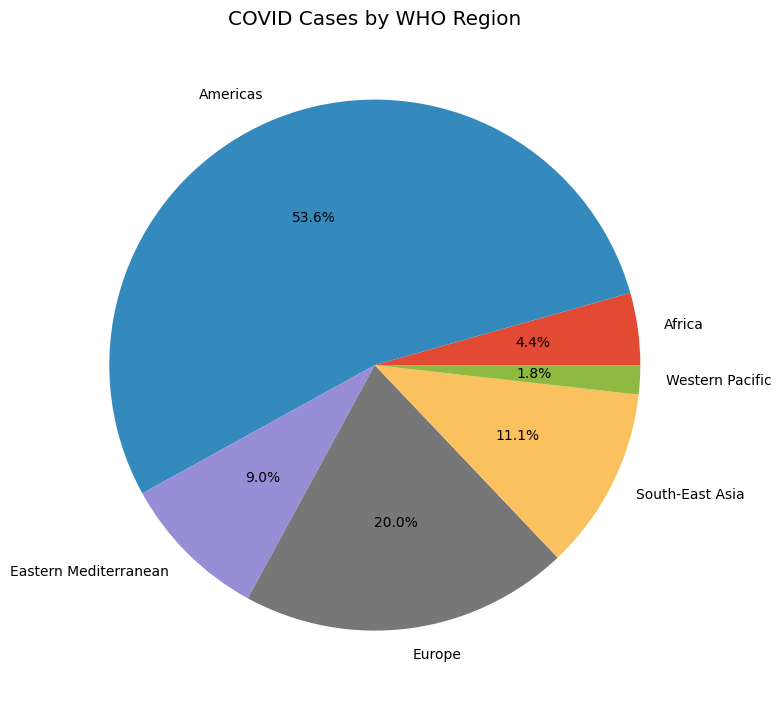


Stakeholder Insight:
Helps international organizations understand which global regions contribute most to infections.



In [18]:
# Visualization 9 
# Regional Case Distribution 

region_cases = df.groupby("WHO_Region")["Confirmed"].sum()

plt.figure(figsize=(8,8))
plt.pie(region_cases, labels=region_cases.index, autopct='%1.1f%%')

plt.title("COVID Cases by WHO Region")
plt.tight_layout()
plt.savefig("../images/region_case_distribution.png")
plt.show()

print(
'''
Stakeholder Insight:
Helps international organizations understand which global regions contribute most to infections.
'''
)

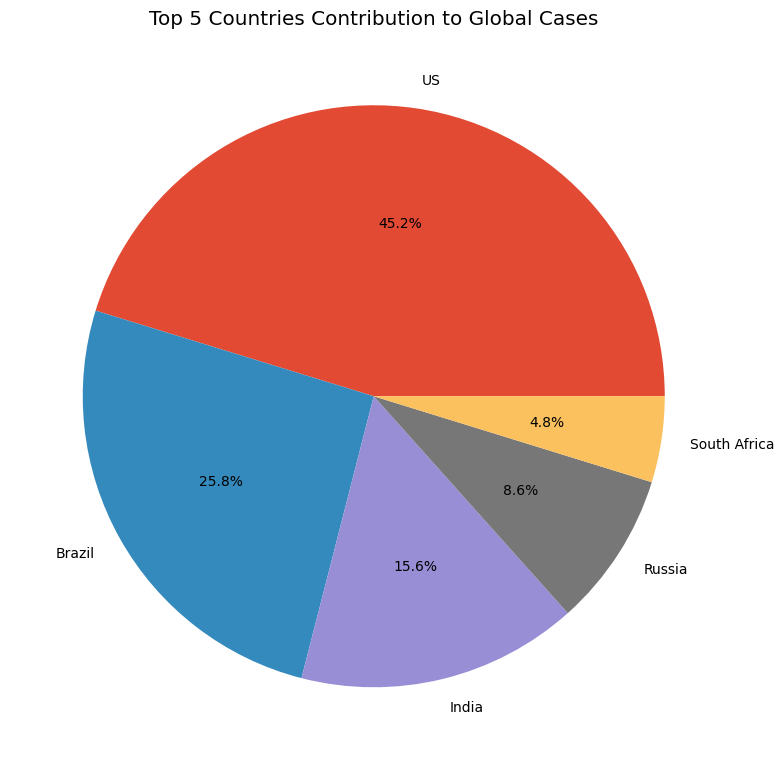


Stakeholder Insight:
Shows that a small number of countries account for a large proportion of global cases.



In [19]:
# Visualization 10 
# Top 5 Countries Contribution 

top5 = df.sort_values("Confirmed", ascending=False).head(5)

plt.figure(figsize=(8,8))
plt.pie(top5["Confirmed"], labels=top5["Country_Region"], autopct='%1.1f%%')

plt.title("Top 5 Countries Contribution to Global Cases")
plt.tight_layout()
plt.savefig("../images/top5_country_contribution.png")
plt.show()

print(
'''
Stakeholder Insight:
Shows that a small number of countries account for a large proportion of global cases.
'''
)

# Key Insights from COVID-19 Data Analysis

**1. Global Infection Concentration**  
A small number of countries account for a disproportionately large share of confirmed COVID-19 cases, indicating major global hotspots that require focused healthcare resources and containment strategies.

**2. Strong Relationship Between Cases and Deaths**  
The correlation analysis shows a strong positive relationship between confirmed cases and deaths, suggesting that controlling infection spread is essential for reducing mortality rates.

**3. Rapid Weekly Growth Indicates Emerging Outbreaks**  
Countries with the highest weekly increase in cases represent potential emerging outbreak zones, highlighting the need for early intervention and stricter containment measures.

**4. Regional Differences in Pandemic Impact**  
The distribution of cases across WHO regions shows uneven pandemic spread, emphasizing that public health responses must be tailored to regional conditions rather than applying uniform global strategies.

**5. Pandemic Outcomes Vary by Country**  
Differences in recovery and fatality patterns suggest that healthcare infrastructure, government response, and population factors play a critical role in determining pandemic outcomes.

# One-Page Insight Summary

## Overview
This exploratory data analysis examined global COVID-19 data across **187 countries**. The dataset contains information about confirmed cases, deaths, recoveries, active cases, and weekly growth in infections.

The analysis focused on identifying **global trends, relationships between pandemic indicators, and countries experiencing extreme outbreak conditions** through data cleaning, visualization, and statistical exploration.

---

## Key Findings

The results show that a **limited number of countries dominate global infection numbers**, indicating major pandemic hotspots where medical resources and public health measures must be concentrated.

Correlation analysis reveals a **strong relationship between confirmed cases and deaths**, emphasizing the importance of controlling infection spread to reduce mortality rates.

Outlier detection identified **countries with exceptionally high case counts compared to the global average**. These extreme cases represent regions that may require urgent public health intervention and stronger containment policies.

Regional analysis shows **uneven pandemic distribution across WHO regions**, suggesting that global health strategies should be tailored to regional conditions rather than applying uniform policies.

---

## Actionable Insights

The analysis suggests three key actions:

- **Prioritize healthcare resources** in countries with the highest confirmed cases to support overwhelmed healthcare systems.
- **Implement early containment measures** in regions experiencing rapid weekly case growth to prevent large-scale outbreaks.
- **Learn from countries with strong recovery performance** to adopt effective healthcare strategies and improve global pandemic response.

---

## Conclusion

This analysis demonstrates how exploratory data analysis and visualization can transform raw pandemic data into meaningful insights. By identifying trends, correlations, and extreme outbreak patterns, the analysis helps policymakers, healthcare organizations, and researchers make **data-driven decisions to manage public health crises more effectively.**